# CSE 144 Final Project | SigLIP 2: Head Only, Full Dataset
**Due: June 10, 2026**

Trains only the classification head on top of a frozen SigLIP 2 (ViT-SO400M, 378×378) backbone using the **full 1079-image training set** (no validation split). The backbone is never unfrozen. Checkpoints are saved every 10 epochs and at the end of training.

## 1. Setup & Imports

In [1]:
import os
import random
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2 as T
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Change SEED to 33, 42 for the 2nd and 3rd ensemble runs
SEED = 52
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
print(f'Seed: {SEED}')

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Seed: 52


## 2. Data Loading & Augmentation

SigLIP 2 uses 378×378 input resolution and [-1, 1] normalization (mean=0.5, std=0.5).

We resize to 432×432 first to give RandomCrop headroom, then crop to 378×378.
The full 1079-image training set is used — no validation split.

In [3]:
# ---- CHANGE THIS to wherever you unzipped the Kaggle dataset ----
DATA_DIR = '.'
# -----------------------------------------------------------------

# SigLIP 2 uses [-1, 1] normalization
SIGLIP_MEAN = [0.5, 0.5, 0.5]
SIGLIP_STD  = [0.5, 0.5, 0.5]

# Resize to 432 to allow 378 random crop headroom (~14% margin)
train_transform = transforms.Compose([
    transforms.Resize((432, 432)),
    transforms.RandomCrop(378),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=SIGLIP_MEAN, std=SIGLIP_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((378, 378)),
    transforms.ToTensor(),
    transforms.Normalize(mean=SIGLIP_MEAN, std=SIGLIP_STD),
])

# Full dataset — no validation split
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
# ImageFolder sorts folders alphabetically ("10" before "2"), remap to numeric order
train_dataset.class_to_idx = {cls: int(cls) for cls in train_dataset.classes}
train_dataset.samples = [(path, int(train_dataset.classes[lbl])) for path, lbl in train_dataset.samples]
train_dataset.targets  = [int(train_dataset.classes[lbl]) for lbl in train_dataset.targets]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f'Total training images: {len(train_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Class mapping (first 5): {dict(list(train_dataset.class_to_idx.items())[:5])}')
print(f'Train batches: {len(train_loader)}')

Total training images: 1079
Number of classes: 100
Class mapping (first 5): {'0': 0, '1': 1, '10': 10, '11': 11, '12': 12}
Train batches: 34


## 3. Build the Model

The SigLIP 2 backbone is loaded frozen and never updated. Only the small classification head trains.

Model: `vit_so400m_patch14_siglip_378.webli` (ViT-SO400M, patch 14, 378×378 input)

**Prerequisites:** `pip install timm`

In [4]:
NUM_CLASSES = 100

class SigLIP2HeadClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # num_classes=0 removes timm's built-in head — forward() returns feature vectors
        self.backbone = timm.create_model(
            'vit_so400m_patch14_siglip_378.webli',
            pretrained=True,
            num_classes=0
        )
        # Backbone is permanently frozen — no gradient storage needed
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(self.backbone.num_features, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():  # no gradients through backbone saves memory
            features = self.backbone(x)
        return self.head(features)

model = SigLIP2HeadClassifier(NUM_CLASSES).to(device)
print(f'Model ready. Feature dimension: {model.backbone.num_features}')
print(f'Head: {model.head}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Model ready. Feature dimension: 1152
Head: Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1152, out_features=100, bias=True)
)
Trainable parameters: 115,300


## 4. Train the Head

Only the classification head trains — the backbone is permanently frozen.
We train on the full 1079-image dataset. Checkpoints are saved every 10 epochs and at the end.
CutMix regularizes the small head against overfitting on ~10 images per class.

In [4]:
criterion = nn.CrossEntropyLoss()
cutmix    = T.CutMix(num_classes=NUM_CLASSES)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = cutmix(images, labels)
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels.argmax(1)).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

EPOCHS    = 50
optimizer = optim.Adam(model.head.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, train_accs = [], []

print('=== Training head only (SigLIP 2 backbone permanently frozen) ===')
for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    scheduler.step()
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {tr_loss:.3f} Acc: {tr_acc:.3f}')
    if (epoch + 1) % 10 == 0:
        ckpt = f'SigLIP2_full_model_h{SEED}_ep{epoch+1}.pth'
        torch.save(model.state_dict(), ckpt)
        print(f'  -> Checkpoint saved: {ckpt}')

# Final checkpoint (used for inference)
torch.save(model.state_dict(), f'SigLIP2_full_model_h{SEED}.pth')
print(f'\nFinal model saved as SigLIP2_full_model_h{SEED}.pth')

=== Training head only (SigLIP 2 backbone permanently frozen) ===
Epoch 01/50 | Train Loss: 4.199 Acc: 0.125
Epoch 02/50 | Train Loss: 3.046 Acc: 0.448
Epoch 03/50 | Train Loss: 2.330 Acc: 0.624
Epoch 04/50 | Train Loss: 2.113 Acc: 0.598
Epoch 05/50 | Train Loss: 1.913 Acc: 0.704
Epoch 06/50 | Train Loss: 1.861 Acc: 0.715
Epoch 07/50 | Train Loss: 1.763 Acc: 0.689
Epoch 08/50 | Train Loss: 1.627 Acc: 0.720
Epoch 09/50 | Train Loss: 1.554 Acc: 0.758
Epoch 10/50 | Train Loss: 1.655 Acc: 0.753
  -> Checkpoint saved: SigLIP2_full_model_h52_ep10.pth
Epoch 11/50 | Train Loss: 1.386 Acc: 0.814
Epoch 12/50 | Train Loss: 1.608 Acc: 0.839
Epoch 13/50 | Train Loss: 1.558 Acc: 0.774
Epoch 14/50 | Train Loss: 1.612 Acc: 0.763
Epoch 15/50 | Train Loss: 1.477 Acc: 0.745
Epoch 16/50 | Train Loss: 1.607 Acc: 0.709
Epoch 17/50 | Train Loss: 1.558 Acc: 0.785
Epoch 18/50 | Train Loss: 1.538 Acc: 0.769
Epoch 19/50 | Train Loss: 1.474 Acc: 0.797
Epoch 20/50 | Train Loss: 1.371 Acc: 0.791
  -> Checkpoint sav

## 5. Plot Training Curves

Include these plots in your report!

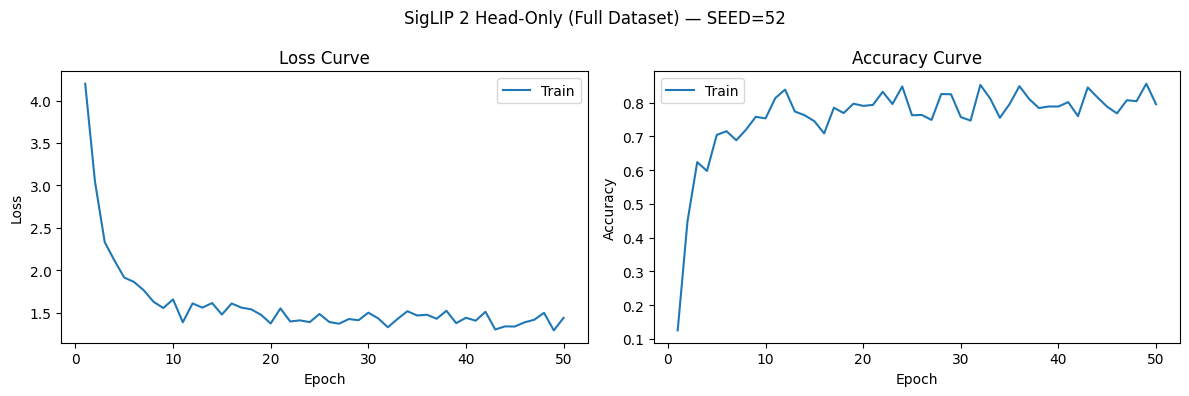

Saved siglip2_full_training_curves_h52.png


In [5]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, label='Train')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss Curve'); ax1.legend()

ax2.plot(epochs_range, train_accs, label='Train')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy Curve'); ax2.legend()

plt.suptitle(f'SigLIP 2 Head-Only (Full Dataset) — SEED={SEED}')
plt.tight_layout()
plt.savefig(f'siglip2_full_training_curves_h{SEED}.png', dpi=150)
plt.show()
print(f'Saved siglip2_full_training_curves_h{SEED}.png')

## 6. Generate Kaggle Submission

Load all 3 ensemble models (SEED=52, 33, 42), run TTA on each test image, average predictions, write `submission.csv`.

In [6]:
import torch.nn.functional as F
import numpy as np

TTA_RUNS = 5

test_dir   = os.path.join(DATA_DIR, 'test')
test_files = sorted(os.listdir(test_dir), key=lambda x: int(x.split('.')[0]))

tta_transform = transforms.Compose([
    transforms.Resize((432, 432)),
    transforms.RandomCrop(378),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=SIGLIP_MEAN, std=SIGLIP_STD),
])

# Run inference with SigLIP2 model only
model.load_state_dict(torch.load(f'SigLIP2_full_model_h{SEED}_ep50.pth', map_location=device))
model.eval()

all_probs = []
with torch.no_grad():
    for fname in test_files:
        img = Image.open(os.path.join(test_dir, fname)).convert('RGB')
        probs = F.softmax(model(eval_transform(img).unsqueeze(0).to(device)), dim=1)
        for _ in range(TTA_RUNS):
            probs += F.softmax(model(tta_transform(img).unsqueeze(0).to(device)), dim=1)
        probs /= (TTA_RUNS + 1)
        all_probs.append(probs.cpu().numpy())

# Save probabilities as numpy array for later ensemble combining
siglip2_probs = np.array(all_probs)
np.save(f'siglip2_probs_h{SEED}.npy', siglip2_probs)
print(f'Saved siglip2_probs_h{SEED}.npy with shape {siglip2_probs.shape}')

/tmp/ipykernel_2466/917259173.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'SigLIP2_full_model_h{SEED}_ep50.pth', map_location=devi

Saved siglip2_probs_h52.npy with shape (1036, 1, 100)


In [7]:
import torch.nn.functional as F
import numpy as np
from transformers import AutoTokenizer, AutoModel

# Category-level prompts for each of the 100 classes
class_prompts = (
    ["a photo of food"] * 30 +          # classes 0-29
    ["a photo of a flower"] * 20 +      # classes 30-49
    ["a photo of a car"] * 20 +         # classes 50-69
    ["a photo of an aircraft"] * 30     # classes 70-99
)

# Load original SigLIP text encoder (publicly available, no auth needed)
tokenizer = AutoTokenizer.from_pretrained("google/siglip-so400m-patch14-384")
text_encoder = AutoModel.from_pretrained("google/siglip-so400m-patch14-384").to(device)
text_encoder.eval()

# Encode class prompts as text vectors
with torch.no_grad():
    inputs = tokenizer(class_prompts, padding=True, return_tensors="pt").to(device)
    text_features = text_encoder.get_text_features(**inputs)
    text_features = F.normalize(text_features, dim=-1)

print(f'Text features shape: {text_features.shape}')

# Use SigLIP2 backbone to get image features for cosine similarity
siglip_backbone = model.backbone
siglip_backbone.eval()

text_probs = []
with torch.no_grad():
    for fname in test_files:
        img = Image.open(os.path.join(test_dir, fname)).convert('RGB')
        img_tensor = eval_transform(img).unsqueeze(0).to(device)
        img_features = F.normalize(siglip_backbone(img_tensor), dim=-1)
        # Cosine similarity between image and all 100 text embeddings
        similarity = (img_features @ text_features.T).squeeze(0)
        probs = F.softmax(similarity * 10, dim=0)  # temperature scaling
        text_probs.append(probs.cpu().numpy())

text_probs = np.array(text_probs)
np.save(f'text_probs_h{SEED}.npy', text_probs)
print(f'Saved text_probs_h{SEED}.npy with shape {text_probs.shape}')

Text features shape: torch.Size([100, 1152])
Saved text_probs_h52.npy with shape (1036, 100)


In [11]:
pe_probs     = np.load('pe_probs_h52.npy')
siglip_probs = np.load('siglip2_probs_h52.npy')
text_probs   = np.load('text_probs_h52.npy')

# Weighted combination — PE leads, SigLIP2 adds diversity, text breaks ties
combined = (0.1 * pe_probs + 0.5 * siglip_probs + 0.4 * text_probs.reshape(1036, 1, 100))
predictions = combined.argmax(axis=2).flatten()

submission = pd.DataFrame({'ID': test_files, 'Label': predictions})
submission = submission.sort_values(
    by='ID', key=lambda x: x.map(lambda f: int(f.split('.')[0]))
).reset_index(drop=True)
submission.to_csv('submission.csv', index=False)
print(f'Saved submission.csv with {len(submission)} predictions')
print(submission.head(10))

Saved submission.csv with 1036 predictions
      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     51
4  4.jpg     42
5  5.jpg     89
6  6.jpg      3
7  7.jpg     28
8  8.jpg     71
9  9.jpg     71


## 7. Save Model Weights for Google Drive

After all 3 training runs, upload `SigLIP2_full_model_h52.pth`, `SigLIP2_full_model_h33.pth`, and `SigLIP2_full_model_h42.pth` to Google Drive and paste the link in your GitHub README.

In [ ]:
for seed in [52, 33, 42]:
    path = f'SigLIP2_full_model_h{seed}.pth'
    exists = os.path.exists(path)
    print(f'{path}: {"✓ exists" if exists else f"✗ MISSING — run training with SEED={seed}"}')

print('\nFiles to submit/upload:')
print('  submission.csv                         -> Kaggle')
print('  SigLIP2_full_model_h52/33/42.pth       -> Google Drive (link in README)')
print('  siglip2_full_training_curves_h*.png    -> include in report')
print('  this .ipynb file                       -> GitHub repo')